In [3]:
# Jupyter notebook for running test cases for DC-motor encoder PID control project

In [5]:
# install pyserial for serial logging
pip install pyserial

SyntaxError: invalid syntax (3443986793.py, line 2)

In [1]:
# Import neccessary libraries
import serial
import time
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

command_counter = 0 # Python to keep track of commands as wel

In [3]:
# RESET THE CONNECTION IF NEEDED

try:
    ser.close()
    print("Closed existing connection") # resets the connection if it's open
except NameError:
    print("No existing connection to close")
except Exception as e:
    print(f"Error closing: {e}")

No existing connection to close


In [5]:
# CONNECT TO THE ARDUINO

SERIAL_PORT = '/dev/cu.usbmodem1101' # this specifies the port the aduino uses
BAUD_RATE = 9600 # need to use same BAUD rate as computer

ser = serial.Serial(SERIAL_PORT, BAUD_RATE, timeout = 0.1) # check every 0.1 seconds for the serial
time.sleep(2) # opening this connection will reset the arduino, sleep gives time to reboot before anything is set
ser.reset_input_buffer() # clears out garbage data that arrived during the reboot
print(f"Connected to {SERIAL_PORT}")

Connected to /dev/cu.usbmodem1101


In [7]:
# NOTE

# if unable to connect, may need to run in terminal
# lsof | grep usbmodem
# and kill a connection that has already been established by aruino "kill 5031" or "kill 10651"

In [9]:
# TEST MATRIX

# creates a matrix with various tests involving degrees of rotation, differing direction, and starting conditions
step_sizes = [10, 45, 90, 180, 360] # in degrees of rotation
directions = [1, -1]
starting_conditions = ['rest', 'in_motion_same','in_motion_reversal']
repeats = 3

test_matrix = [] # initialize a list of dictionaries
for size in step_sizes:
    for direction in directions:
        for start in starting_conditions:
            for rep in range(1, repeats + 1):
                test_matrix.append({
                    'step_size': size,
                    'direction': direction,
                    'target': size * direction,
                    'start_condition': start,
                    'rep': rep
                })

print(f"Total tests to run: {len(test_matrix)}")

Total tests to run: 90


In [11]:
# HELPER FUNCTIONS


# given a float target_angle, writes that target_angle to the Arduino while updating Python's command_counter
def send_target(target_angle):
    global command_counter # ensures python alters the global command counter variable
    command_counter += 1
    ser.write(f"{target_angle}\n".encode()) # builds a text string with trailing newline, sends it to Arduino
    return command_counter

# 
def wait_for_settle(cmd_id, tolerance_deg=2.0, min_settle_samples=5, max_wait_sec=10.0):
    # Blocks until the motor has genuinely settled at the last commanded target, or times out.
    consec_in_band = 0
    start = time.time()
    while time.time() - start < max_wait_sec:
        try:
            line = ser.readline().decode(errors='ignore').strip()
        except Exception:
            continue
        if not line:
            continue
        parts = line.split(',')
        if len(parts) != 4:
            continue
        try:
            this_cmd_id = int(float(parts[0]))
            current, target = float(parts[2]), float(parts[3])
        except ValueError:
            continue
        if this_cmd_id != cmd_id:
            continue
        error = abs(current - target)
        consec_in_band = consec_in_band + 1 if error <= tolerance_deg else 0
        if consec_in_band >= min_settle_samples:
            return True
    return False


# takes in a command ID, Reads the inputs from serial, and puts them in a dataframe which is returned. Only 
# expected_commmand_id: command ID that log_response expects us to be on right now
# tolerance_deg: defines where steady state is acheived 
# min_settled_samples: defines number of consecutive samples in steady state neccssary to conclude the test
# max_duration_sec: defines the max amount of time for a test to run, used if no steady state is achieved
def log_response(expected_command_id, tolerance_deg=2.0, min_settle_samples=5, max_duration_sec=15.0):
    data = []
    consec_in_band = 0 # how many consecutive readings in a row have landed withn tolerance_deg of target
    start_wall_time = time.time() # start time of the function 

    while time.time() - start_wall_time < max_duration_sec: # exit the loop if reached max_duration_sec
        try:
            line = ser.readline().decode(errors='ignore').strip() # read lines and decode them
        except Exception:
            continue
        if not line:
            continue
        parts = line.split(',')
        if len(parts) != 4: # we expect command_ID, time, target, and value from the serial for each line
            continue
        try:
            cmd_id = int(float(parts[0]))
            t_ms, current, target = float(parts[1]), float(parts[2]), float(parts[3])
        except ValueError:
            continue

        if cmd_id != expected_command_id: # if cmd_ID doesn't match the one we're on right now, skip it
            continue  

        data.append((t_ms, current, target)) # add to our data

        error = abs(current - target)
        consec_in_band = consec_in_band + 1 if error <= tolerance_deg else 0
        if consec_in_band >= min_settle_samples:
            break  # Break the loop once min_settled_samples has been reached

    df = pd.DataFrame(data, columns=['t_ms', 'current_angle', 'target_angle'])
    if len(df) > 0:
        df['t_sec'] = (df['t_ms'] - df['t_ms'].iloc[0]) / 1000.0
    return df

In [13]:
# Takes in a test (a dictionary with step size, direction, repeats, and starting conditions)
# 
def run_single_test(test):
    if test['start_condition'] == 'rest':
        cmd_id_setup = send_target(0)
        settled = wait_for_settle(cmd_id_setup)
        if not settled:
            print(f"  WARNING: rest baseline never settled for test {test}")
    elif test['start_condition'] == 'in_motion_same':
        intermediate = test['target'] / 2 if test['target'] != 0 else 45
        send_target(intermediate)
        time.sleep(0.3)
    else:
        intermediate = -test['target'] / 2 if test['target'] != 0 else 45
        send_target(intermediate)
        time.sleep(0.3)

    cmd_id = send_target(test['target'])  # the ID that matters - this is the real test's command
    df = log_response(cmd_id, max_duration_sec=15.0)
    if len(df) == 0:
        print(f"  WARNING: no data logged for test {test}")
    return df

In [15]:
# RUN ALL TESTS
os.makedirs('pid_test_logs', exist_ok=True)

all_runs = []

for i, test in enumerate(test_matrix):
    print(f"Running test {i+1}/{len(test_matrix)}: {test}")
    df = run_single_test(test)
    df['test_id'] = i
    for key, val in test.items():
        df[key] = val
    filename = f"pid_test_logs/test_{i:03d}_size{test['step_size']}_dir{test['direction']}_{test['start_condition']}_rep{test['rep']}.csv"
    df.to_csv(filename, index=False)
    all_runs.append(df)

raw_data = pd.concat(all_runs, ignore_index=True)
raw_data.to_csv('pid_test_logs/all_runs_raw.csv', index=False)
print("All tests complete.")

Running test 1/90: {'step_size': 10, 'direction': 1, 'target': 10, 'start_condition': 'rest', 'rep': 1}


ValueError: too many values to unpack (expected 2)

In [21]:
# COMPUTE THE TEST METRICS

def compute_metrics(df, tolerance_deg=2.0):
    if len(df) == 0:
        return {'settling_time_sec': np.nan, 'steady_state_error_deg': np.nan}

    target = df['target_angle'].iloc[-1]
    error = (df['current_angle'] - target).values
    t = df['t_sec'].values

    within_band = np.abs(error) <= tolerance_deg # true / false array, one entry per sample when within 2 degrees of tolerance

    settling_time = np.nan
    for idx in range(len(within_band)):
        if within_band[idx] and np.all(within_band[idx:]):
            settling_time = t[idx]
            break

    final_window_mask = t >= (t[-1] - 1.0)
    steady_state_error = np.mean(np.abs(error[final_window_mask])) if final_window_mask.any() else np.nan

    return {'settling_time_sec': settling_time, 'steady_state_error_deg': steady_state_error}

In [23]:
# SUMMARY TABLE

summary_rows = []
for i, test in enumerate(test_matrix):
    df = all_runs[i]
    metrics = compute_metrics(df, tolerance_deg=2.0)
    row = {**test, **metrics}
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv('pid_test_logs/summary.csv', index=False)
summary_df

,step_size,direction,target,start_condition,rep,settling_time_sec,steady_state_error_deg
0,10,1,10,rest,1,10.96,1.766538
1,10,1,10,rest,2,0.08,1.676538
2,10,1,10,rest,3,0.04,0.989200
3,10,1,10,in_motion_same,1,NaN,3.066800
4,10,1,10,in_motion_same,2,NaN,2.839600
...,...,...,...,...,...,...,...
85,360,-1,-360,in_motion_same,2,NaN,8.000000
86,360,-1,-360,in_motion_same,3,NaN,8.000000
87,360,-1,-360,in_motion_reversal,1,NaN,4.000000
88,360,-1,-360,in_motion_reversal,2,NaN,4.000000


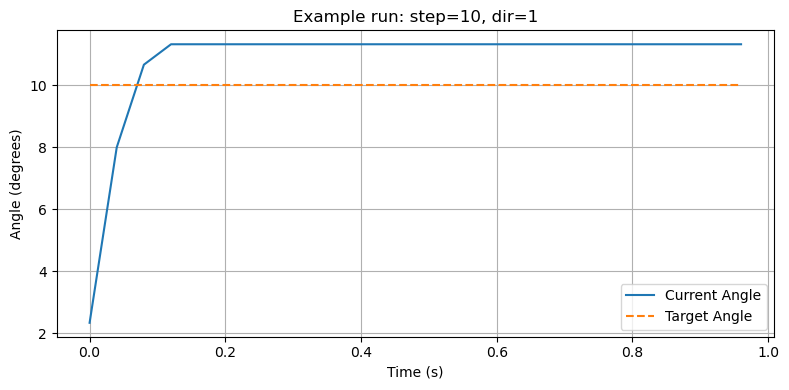

In [25]:
# EXAMPLE PLOT

example = all_runs[5]
plt.figure(figsize=(8, 4))
plt.plot(example['t_sec'], example['current_angle'], label='Current Angle')
plt.plot(example['t_sec'], example['target_angle'], label='Target Angle', linestyle='--')
plt.xlabel('Time (s)')
plt.ylabel('Angle (degrees)')
plt.title(f"Example run: step={example['step_size'].iloc[0]}, dir={example['direction'].iloc[0]}")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('pid_test_logs/example_run.png', dpi=150)
plt.show()

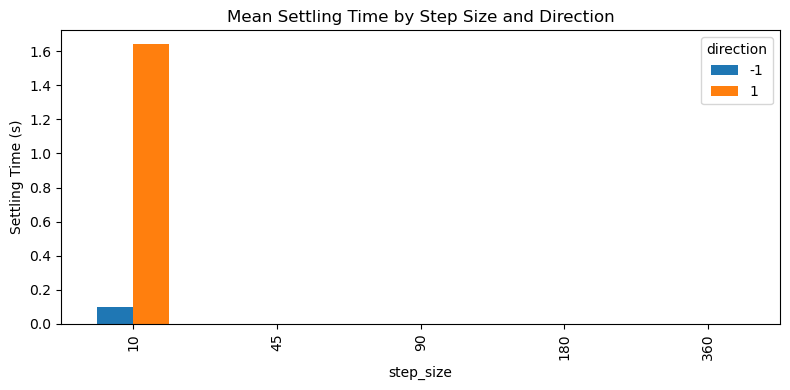

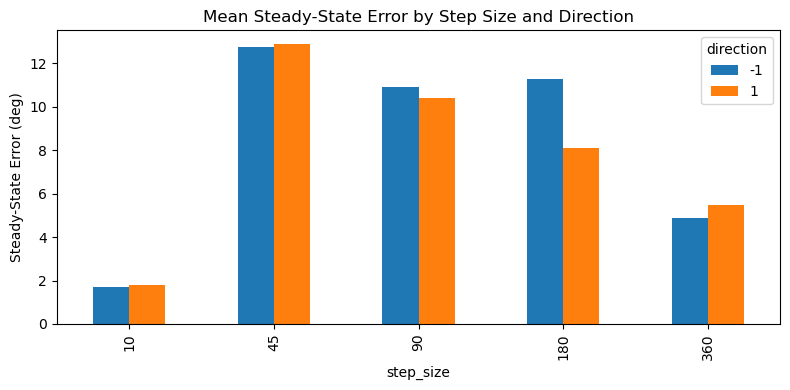

In [27]:
# SUMMARY BAR CHARTS

pivot_settle = summary_df.groupby(['step_size', 'direction'])['settling_time_sec'].mean().unstack()
pivot_settle.plot(kind='bar', figsize=(8, 4), title='Mean Settling Time by Step Size and Direction')
plt.ylabel('Settling Time (s)')
plt.tight_layout()
plt.savefig('pid_test_logs/settling_time_summary.png', dpi=150)
plt.show()

pivot_error = summary_df.groupby(['step_size', 'direction'])['steady_state_error_deg'].mean().unstack()
pivot_error.plot(kind='bar', figsize=(8, 4), title='Mean Steady-State Error by Step Size and Direction')
plt.ylabel('Steady-State Error (deg)')
plt.tight_layout()
plt.savefig('pid_test_logs/steady_state_error_summary.png', dpi=150)
plt.show()

In [29]:
step10_rows = summary_df[summary_df['step_size'] == 10].sort_values('settling_time_sec', ascending=False)
step10_rows.head(10)

,step_size,direction,target,start_condition,rep,settling_time_sec,steady_state_error_deg
0,10,1,10,rest,1,10.96,1.766538
16,10,-1,-10,in_motion_reversal,2,0.16,1.810385
6,10,1,10,in_motion_reversal,1,0.12,1.450769
7,10,1,10,in_motion_reversal,2,0.12,1.292308
8,10,1,10,in_motion_reversal,3,0.12,1.279231
10,10,-1,-10,rest,2,0.12,2.499615
15,10,-1,-10,in_motion_reversal,1,0.12,1.276800
17,10,-1,-10,in_motion_reversal,3,0.12,1.527692
1,10,1,10,rest,2,0.08,1.676538
9,10,-1,-10,rest,1,0.08,0.869600
